In [23]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
import corner

In [56]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)
print(data_air.keys())

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
dict_keys(['time_years', 'time_centered', 'Year', 'Month', 'Monthly_Anomaly', 'Monthly_Anomaly_Unc', 'Annual_Anomaly', 'Annual_Anomaly_Unc', 'Five_Year_Anomaly', 'Five_Year_Anomaly_Unc', 'Ten_Year_Anomaly', 'Ten_Year_Anomaly_Unc', 'Twenty_Year_Anomaly', 'Twenty_Year_Anomaly_Unc'])
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


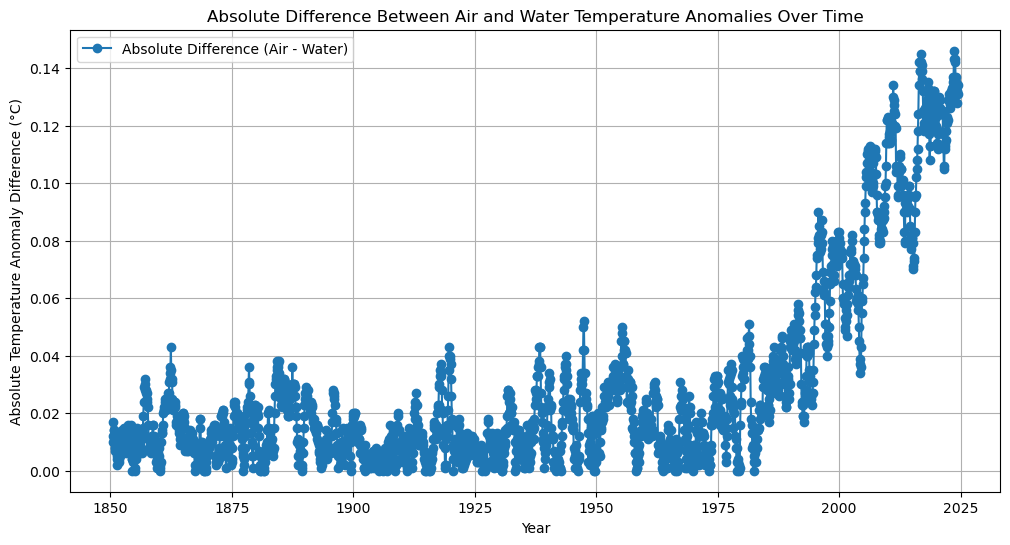

In [15]:
diff = np.abs(data_air['Annual_Anomaly'] - data_water['Annual_Anomaly'])
plt.figure(figsize=(12, 6))
plt.plot(data_air['time_years'], diff, 'o-', label='Absolute Difference (Air - Water)')
plt.xlabel('Year')
plt.ylabel('Absolute Temperature Anomaly Difference (°C)')
plt.title('Absolute Difference Between Air and Water Temperature Anomalies Over Time')
plt.legend()
plt.grid()
plt.show()

In [16]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [ ]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 20 - 10

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 1
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = (cube[0] * 0.002) - 0.001
    params[1] = (cube[1] * 0.2) - 0.1
    params[2] = (cube[2] * 4) - 2

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = (cube[2] * 2.0) - 2.0
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [72]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7251..-81416.7251]*| it/evals=4880/5460 eff=96.4427% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5471
[ultranest]   logZ = -8.143e+04 +- 0.1021
[ultranest] Effective samples strategy satisfied (ESS = 1279.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.10 tail:0.04 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81425.697 +- 0.163
  single instance: logZ = -81425.697 +- 0.146
  bootstrapped   : logZ = -81425.706 +- 0.158
  tail           : logZ = +- 0.038
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3445│ ▁ ▁ ▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇▇▄▄▄▃▂▃▂▁▁▁▁▁  ▁ │0.3531    0.3491 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4404..-74211.4404]*| it/evals=5040/5587 eff=97.1660% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5588
[ultranest]   logZ = -7.422e+04 +- 0.1098
[ultranest] Effective samples strategy satisfied (ESS = 1288.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.11 tail:0.03 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74220.578 +- 0.239
  single instance: logZ = -74220.578 +- 0.147
  bootstrapped   : logZ = -74220.578 +- 0.237
  tail           : logZ = +- 0.031
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3148│ ▁   ▁▁▁▁▁▁▂▂▂▄▅▅▅▇▇▇▇▆▇▅▄▃▃▂▂▁▁▁▁▁▁▁▁ │0.3232    0.3192 +- 0.0010

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6273..-20185.6273]*| it/evals=8880/12127 eff=75.7227% N=400    0   0 
[ultranest] Likelihood function evaluations: 12161
[ultranest]   logZ = -2.02e+04 +- 0.1236
[ultranest] Effective samples strategy satisfied (ESS = 1606.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.10 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.20 bs:0.12 tail:0.01 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20203.282 +- 0.226
  single instance: logZ = -20203.282 +- 0.204
  bootstrapped   : logZ = -20203.263 +- 0.225
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009901│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▆▆▆▇▇▇▆▆▅▅▄▃▂▂▁▁▁▁▁▁▁ ▁ │0.010143    0.010024 +- 0.000029
    b                   : -0.9834│ ▁▁▁▁▁▁▁▁▂▂▂▄▅▅▆▇▇▇▇▇▆▆▆▄▃▂▂▁▁▁▁▁▁▁  

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8216..-18230.8216]*| it/evals=9180/12482 eff=75.9808% N=400    0   0 
[ultranest] Likelihood function evaluations: 12494
[ultranest]   logZ = -1.825e+04 +- 0.18
[ultranest] Effective samples strategy satisfied (ESS = 1587.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18249.180 +- 0.403
  single instance: logZ = -18249.180 +- 0.208
  bootstrapped   : logZ = -18249.169 +- 0.402
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009032│ ▁▁▁▁▁▁▁▁▁▂▁▂▃▃▄▅▆▆▆▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.009249    0.009145 +- 0.000027
    b                   : -0.9096│ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▇▇▇▇▆▄▅▄▃▂▁▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3797..-2138.3797]*| it/evals=10890/18673 eff=59.5961% N=400   0    0  0  
[ultranest] Likelihood function evaluations: 18702
[ultranest]   logZ = -2161 +- 0.1605
[ultranest] Effective samples strategy satisfied (ESS = 1909.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2161.021 +- 0.345
  single instance: logZ = -2161.021 +- 0.230
  bootstrapped   : logZ = -2161.020 +- 0.345
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009926│ ▁   ▁▁▁▁▁▁▁▂▂▃▃▅▆▆▇▆▆▆▅▅▅▃▃▂▂▁▁▁▁▁▁▁▁ │0.00010466    0.00010216 +- 0.00000062
    b                   : -0.01198│ ▁▁▁▁▁▁▁▁▁▂▄▃▃▄▅▆▆▇▆▆▆▅▅▃▂▂▂▁▁▁▁

[ultranest] Explored until L=-2e+03  948.94 [-1949.0044..-1949.0044]*| it/evals=10760/17882 eff=61.5490% N=400   0    0  00 
[ultranest] Likelihood function evaluations: 17927
[ultranest]   logZ = -1971 +- 0.1412
[ultranest] Effective samples strategy satisfied (ESS = 1877.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1971.352 +- 0.386
  single instance: logZ = -1971.352 +- 0.229
  bootstrapped   : logZ = -1971.361 +- 0.386
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008721│ ▁ ▁▁▁▁▁▁▁▁▂▃▂▄▅▅▆▇▇▇▇▇▅▆▄▄▂▂▁▁▁▁▁▁▁▁▁ │0.00009200    0.00008970 +- 0.00000057
    b                   : -0.01023│ ▁▁▁▁▁▁▁▁▁▂▂▃▅▅▅▆▇▇▇▇▆▆▆▄▃▃▃▂▁

[ultranest] Explored until L=-2e+03  681.17 [-1681.2269..-1681.2266]*| it/evals=10120/101993 eff=9.9613% N=400   0  0 
[ultranest] Likelihood function evaluations: 102014
[ultranest]   logZ = -1702 +- 0.1987
[ultranest] Effective samples strategy satisfied (ESS = 1870.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.52, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1701.926 +- 0.515
  single instance: logZ = -1701.926 +- 0.219
  bootstrapped   : logZ = -1701.894 +- 0.515
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02959│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▃▅▆▇▆▇▇▇▆▆▆▃▃▂▂▁▁▁▁▁▁▁▁▁ │0.03689    0.03335 +- 0.00092
    b                   : 0.02153│ ▁▁▁▁▁▁▁▁▁▂▃▃▄▆▆▆▇

[ultranest] Explored until L=-2e+03  687.33 [-1687.3937..-1687.3937]*| it/evals=10080/90484 eff=11.1896% N=400      0 
[ultranest] Likelihood function evaluations: 90526
[ultranest]   logZ = -1708 +- 0.1755
[ultranest] Effective samples strategy satisfied (ESS = 1892.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1708.019 +- 0.333
  single instance: logZ = -1708.019 +- 0.219
  bootstrapped   : logZ = -1708.000 +- 0.332
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0313│ ▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▅▄▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁ │0.0401    0.0352 +- 0.0011
    b                   : 0.02047│ ▁ ▁▁▁▁▁▁▁▁▁▂▂▄▄▅▅▆▆▇▇▇▆▅▄▄▂▂▁▁▁▁▁▁▁▁▁ │0.02182    

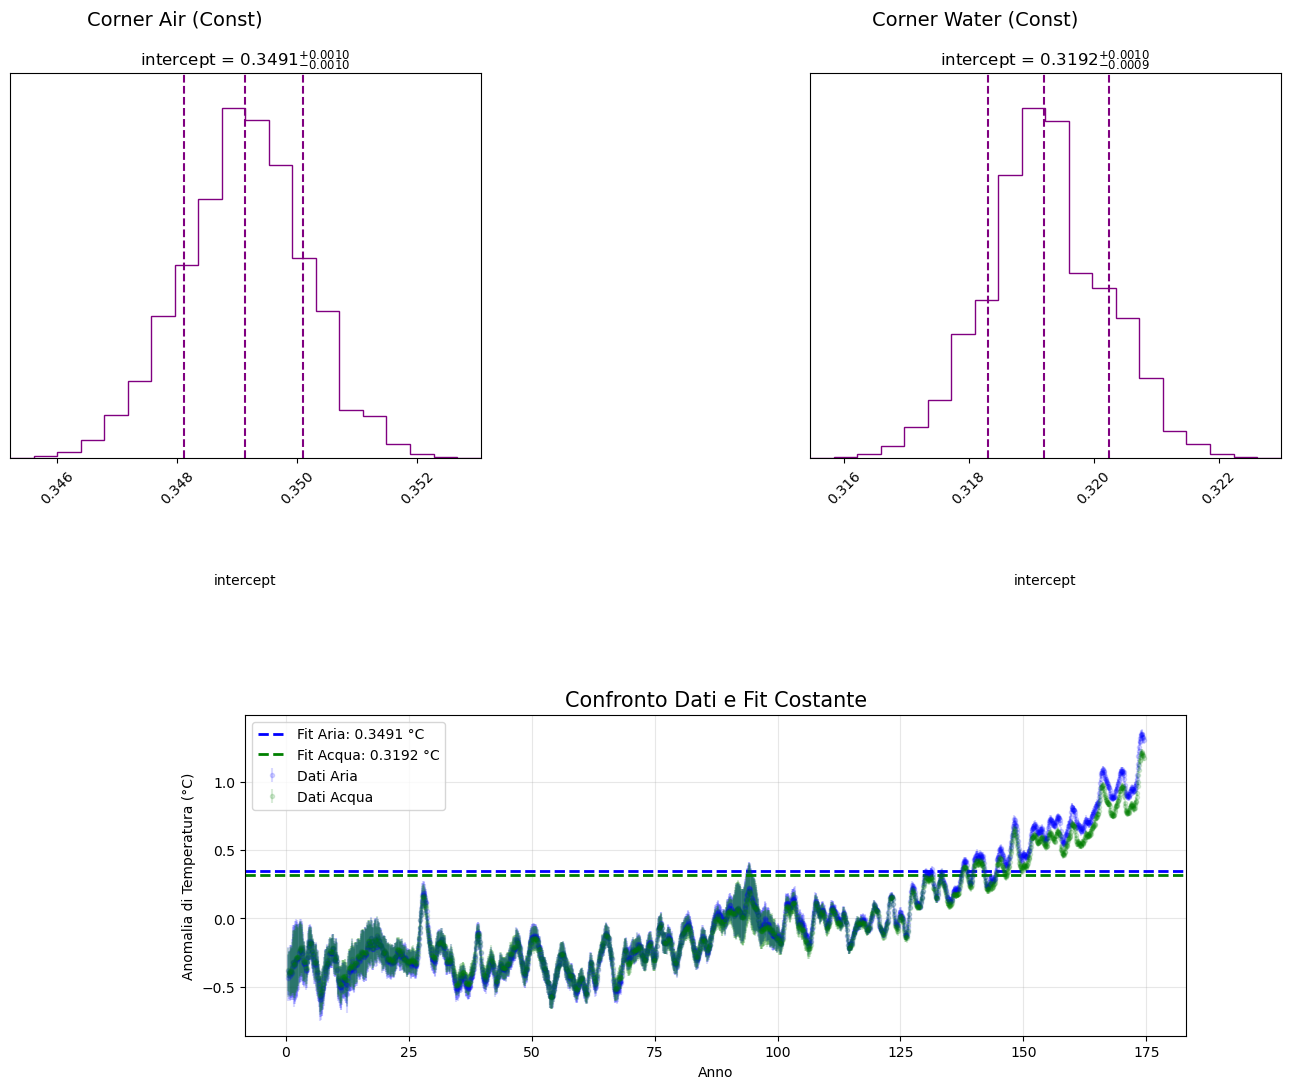

In [66]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Const)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Const)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

median_air = np.median(results['air_const']['samples'])
median_water = np.median(results['water_const']['samples'])


ax.errorbar(data_air['time_centered'], data_air['Annual_Anomaly'], 
            yerr=data_air['Annual_Anomaly_Unc'], fmt='.', color='blue', alpha=0.15, label='Dati Aria')

ax.axhline(median_air, color='blue', linestyle='--', linewidth=2, label=f'Fit Aria: {median_air:.4f} °C')


ax.errorbar(data_water['time_centered'], data_water['Annual_Anomaly'], 
            yerr=data_water['Annual_Anomaly_Unc'], fmt='.', color='green', alpha=0.15, label='Dati Acqua')

ax.axhline(median_water, color='green', linestyle='--', linewidth=2, label=f'Fit Acqua: {median_water:.4f} °C')

ax.set_title('Confronto Dati e Fit Costante', fontsize=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

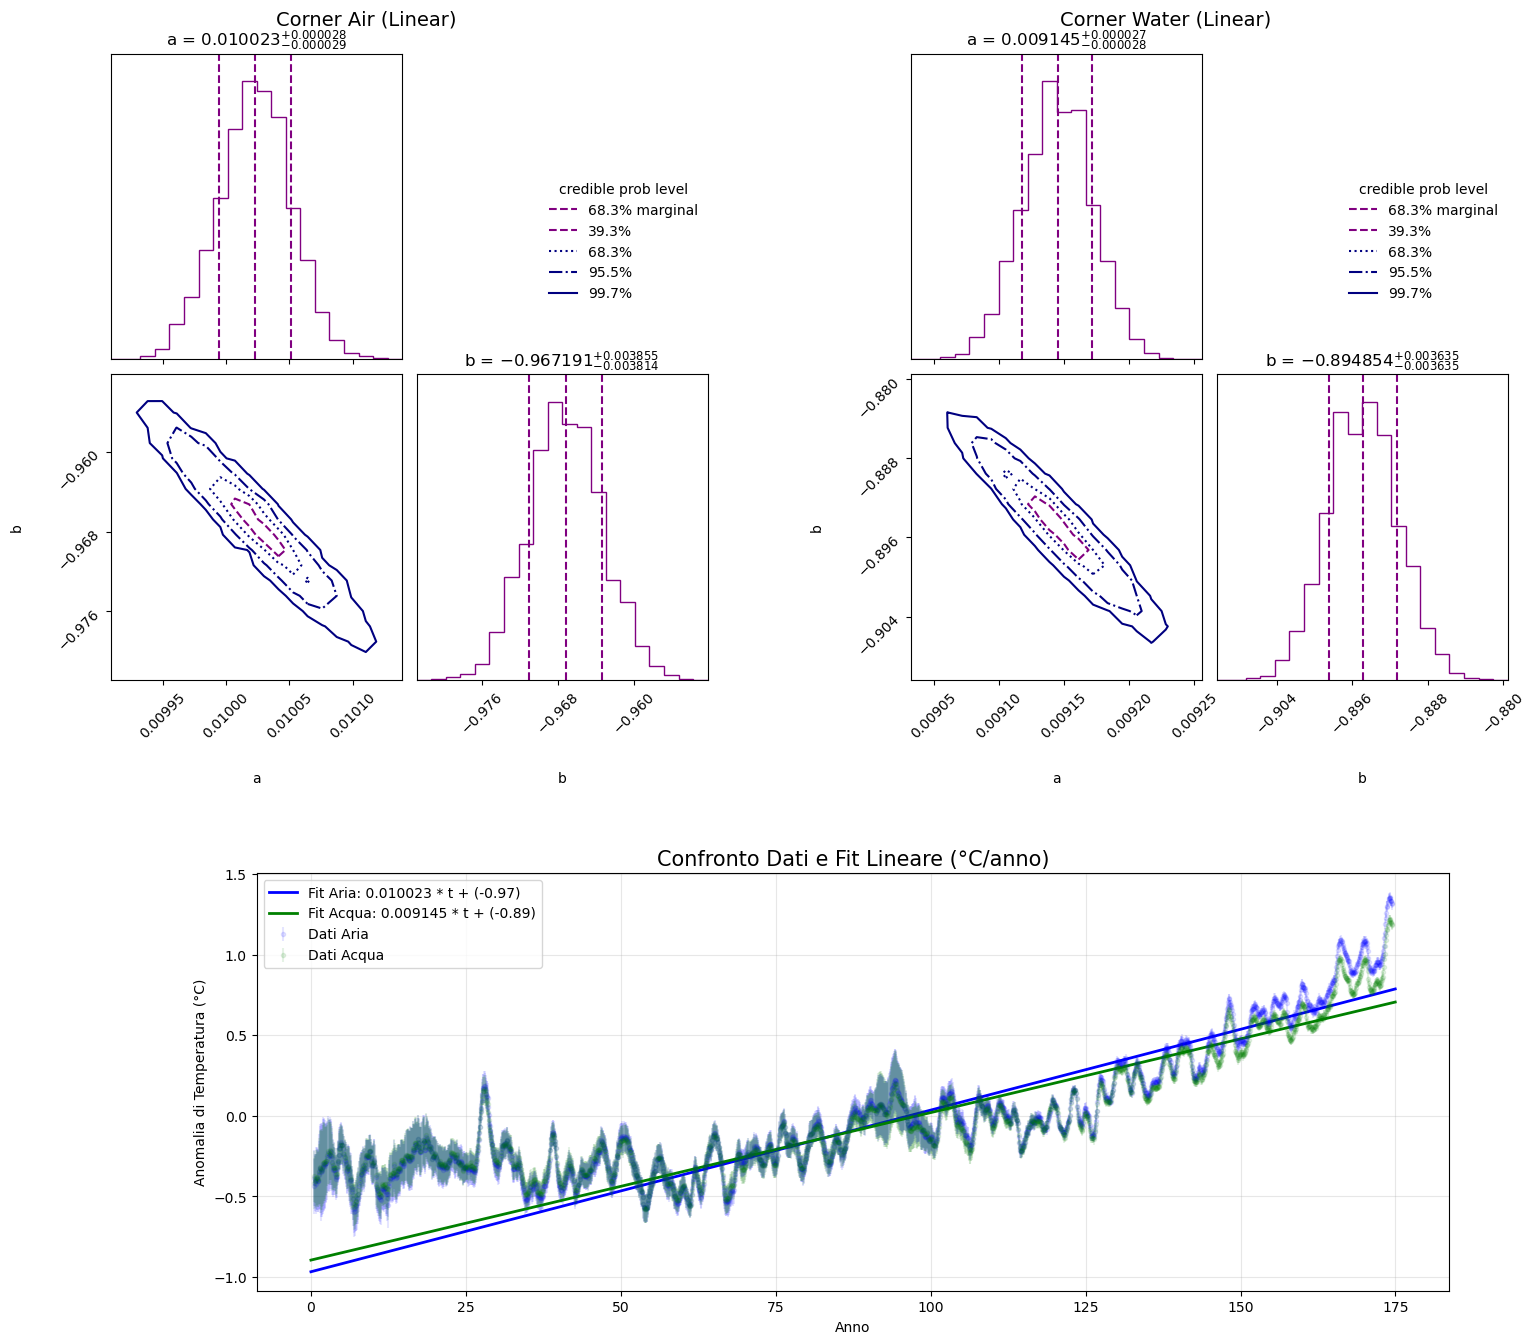

In [67]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

def plot_linear_fit(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    a_med = np.median(samples[:, 0])
    b_med = np.median(samples[:, 1])
    
    x = data['time_centered']
    y_fit = a_med * x + b_med

    ax.errorbar(x, data['Annual_Anomaly'], yerr=data['Annual_Anomaly_Unc'], 
                fmt='.', color=color, alpha=0.1, label=f'Dati {label_prefix}')
    
    ax.plot(x, y_fit, color=color, linewidth=2, 
            label=f'Fit {label_prefix}: {a_med:.6f} * t + ({b_med:.2f})')

plot_linear_fit(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_fit(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

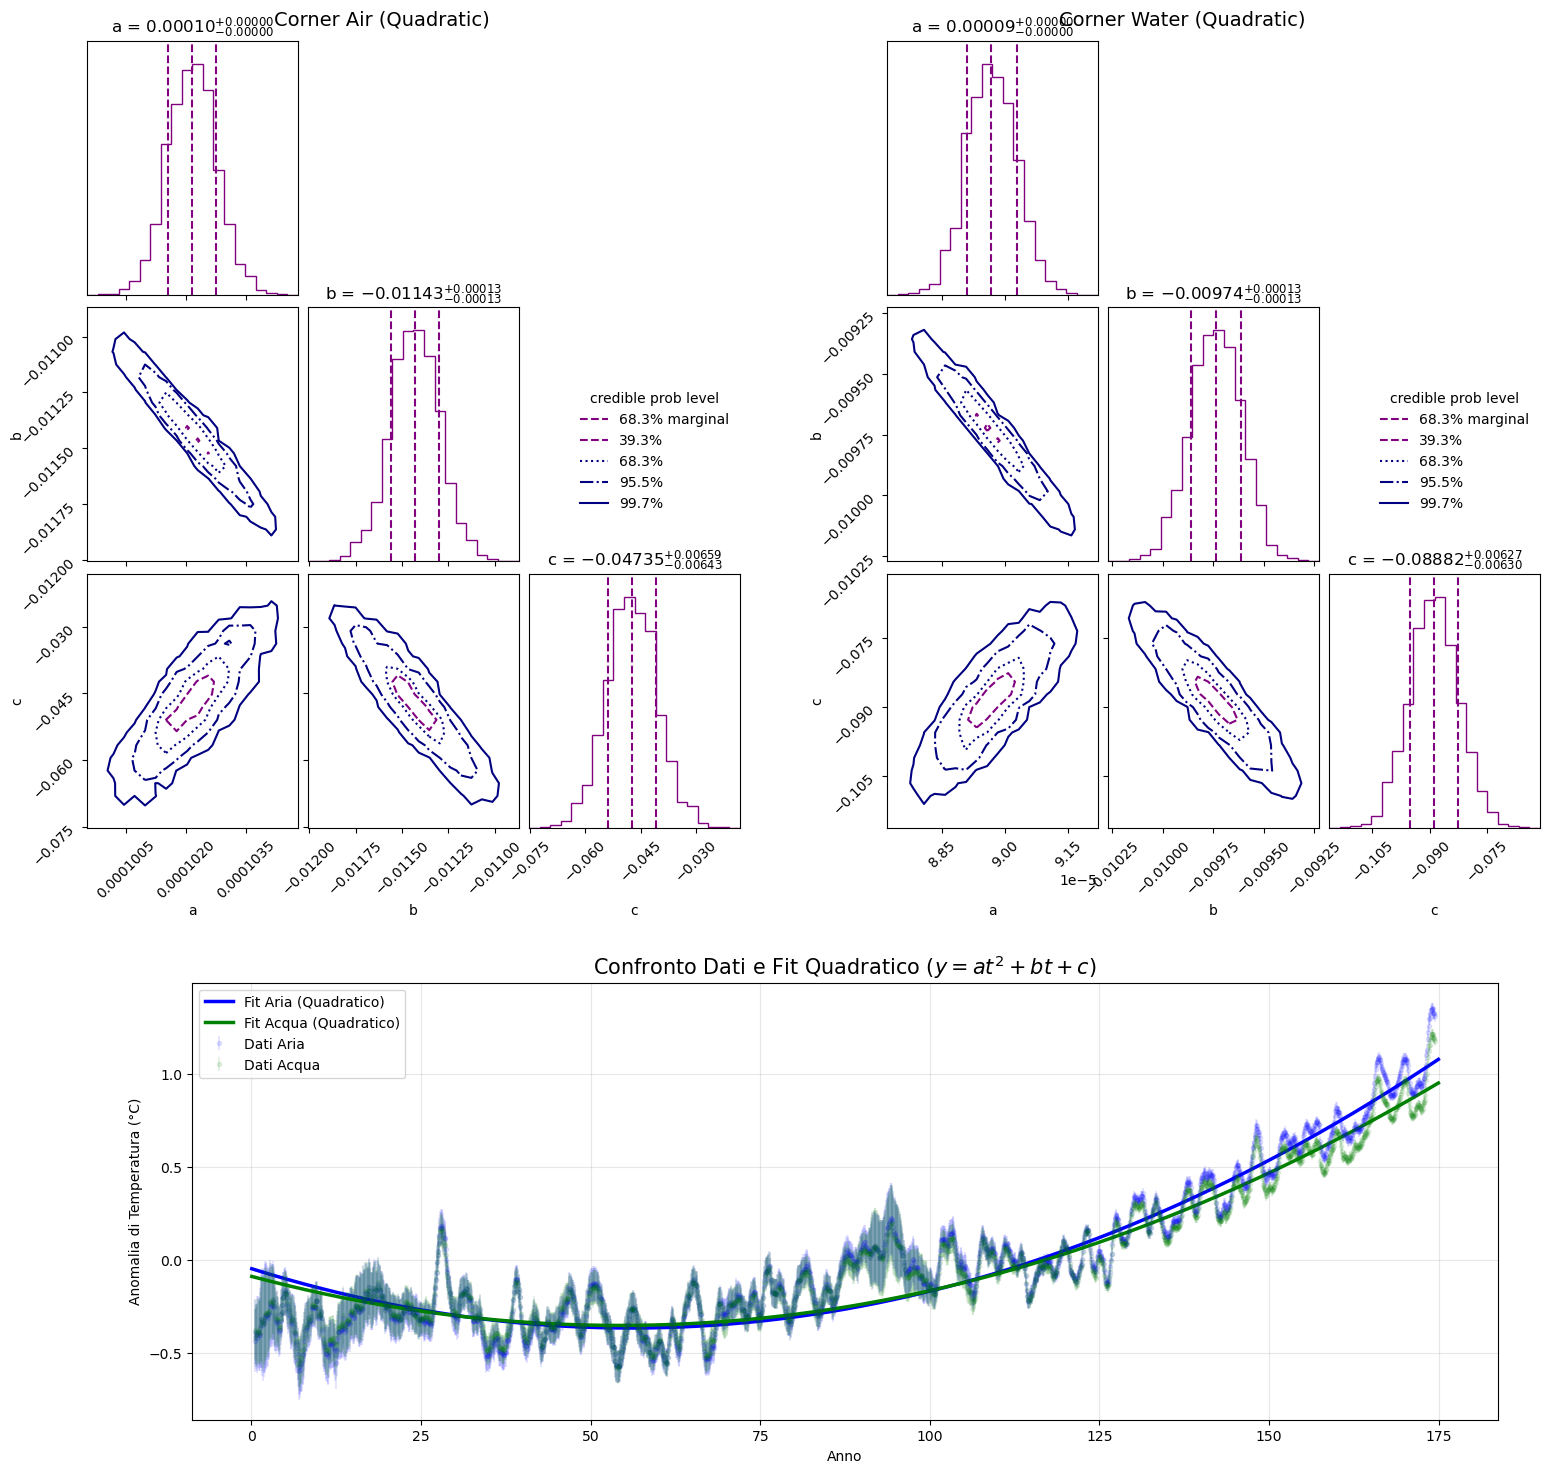

In [70]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.5f')
corner_subfigs[0].suptitle('Corner Air (Quadratic)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.5f')
corner_subfigs[1].suptitle('Corner Water (Quadratic)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

def plot_quadratic_fit(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    a_med = np.median(samples[:, 0])
    b_med = np.median(samples[:, 1])
    c_med = np.median(samples[:, 2])
    
    x = data['time_centered']
    y_fit = a_med * x**2 + b_med * x + c_med

    ax.errorbar(x, data['Annual_Anomaly'], yerr=data['Annual_Anomaly_Unc'], 
                fmt='.', color=color, alpha=0.1, label=f'Dati {label_prefix}')
    
    ax.plot(x, y_fit, color=color, linewidth=2.5, 
            label=f'Fit {label_prefix} (Quadratico)')

plot_quadratic_fit(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_fit(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

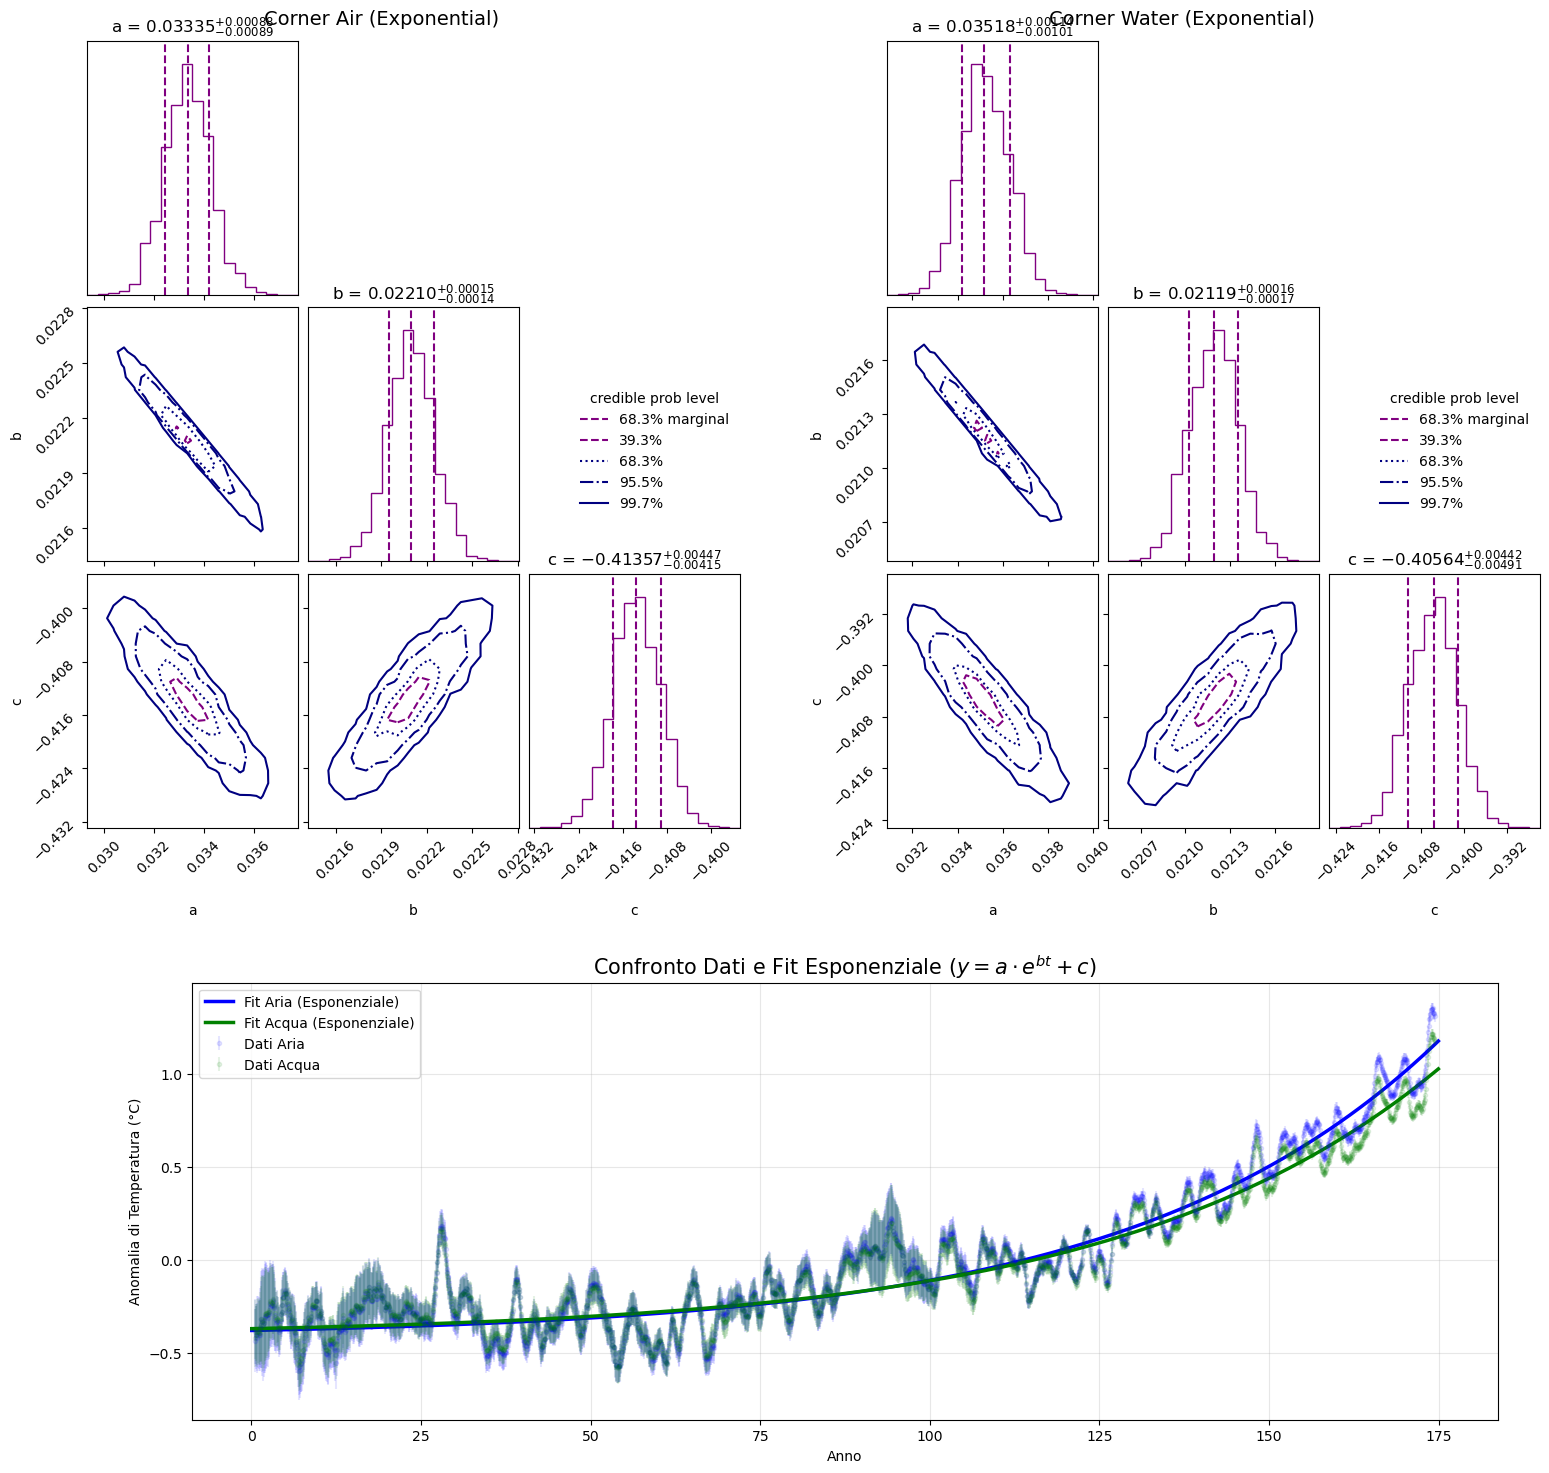

In [73]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.5f')
corner_subfigs[0].suptitle('Corner Air (Exponential)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.5f')
corner_subfigs[1].suptitle('Corner Water (Exponential)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

def plot_exponential_fit(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    a_med = np.median(samples[:, 0])
    b_med = np.median(samples[:, 1])
    c_med = np.median(samples[:, 2])
    
    x = data['time_centered']
    y_fit = a_med * np.exp(b_med * x) + c_med
    
    ax.errorbar(x, data['Annual_Anomaly'], yerr=data['Annual_Anomaly_Unc'], 
                fmt='.', color=color, alpha=0.1, label=f'Dati {label_prefix}')

    ax.plot(x, y_fit, color=color, linewidth=2.5, 
            label=f'Fit {label_prefix} (Esponenziale)')

plot_exponential_fit(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_fit(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend()
ax.grid(alpha=0.3)

plt.show()